Using CPU. Note: This module is much faster with a GPU.


Using EasyOCR for OCR.
Loaded image (270x187)
YOLO detected 0 vehicle(s).
Plate candidate regions found: 1


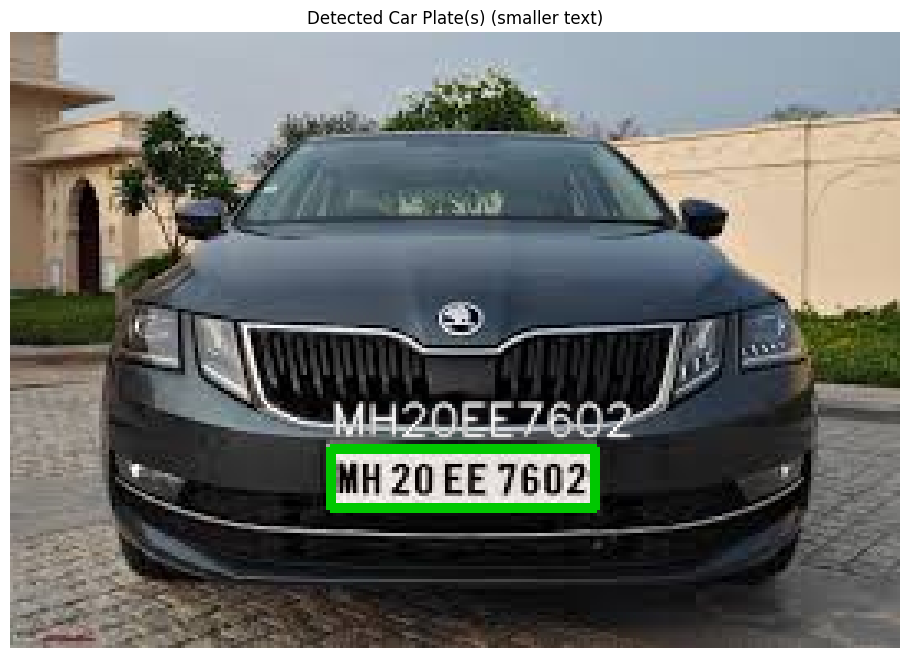


Annotated image saved to: C:\Users\KRISHNENDU\Downloads\mycar_plate_annotated.jpg

Final detected plate(s):
 Plate 1: 'MH20EE7602'  (raw='MH 20 EE 7602')


In [14]:
# Detect only car number plate text (extra small overlay font)
# Annotated image saved to: mycar_plate_annotated.jpg

import cv2, numpy as np, re
from pathlib import Path
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
IMAGE_PATH = r"C:\Users\KRISHNENDU\Downloads\mycar.jpg"
SAVE_ANNOTATED_PATH = r"C:\Users\KRISHNENDU\Downloads\mycar_plate_annotated.jpg"
USE_YOLO_IF_AVAILABLE = True
DEVICE = "cpu"
CONF_THRES = 0.35

TEXT_FONT_SCALE = 0.45      # smaller font size (was 0.7)
TEXT_THICKNESS = 1          # thinner stroke
BOX_THICKNESS = 2           # thinner rectangle line

PLATE_REGEX = [
    r"[A-Z]{2}\s?\d{1,2}\s?[A-Z]{1,2}\s?\d{4}",   # Indian format
    r"[A-Z]{2}-\d{1,2}-[A-Z]{1,2}-\d{1,4}",       # alternate with dashes
    r"[A-Z0-9]{4,10}"                             # generic fallback
]

# ---------- UTILITIES ----------
def show_bgr(img, title=None, figsize=(12,8)):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    if title: plt.title(title)
    plt.axis('off')
    plt.imshow(rgb)
    plt.show()

def draw_boxes(img, boxes, labels=None, color=(0,255,0), thickness=2, font_scale=0.5, text_thickness=1):
    out = img.copy()
    for i, b in enumerate(boxes):
        x1,y1,x2,y2 = map(int, b[:4])
        cv2.rectangle(out, (x1,y1),(x2,y2), color, thickness)
        if labels and i < len(labels):
            cv2.putText(out, str(labels[i]), (x1, max(12, y1-4)),
                        cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), text_thickness, cv2.LINE_AA)
    return out

def normalize_text(s):
    if not s: return ""
    return re.sub(r'[^A-Z0-9 ]', '', s.upper()).strip()

# ---------- OCR setup ----------
use_easyocr = False
try:
    import easyocr
    easyocr_reader = easyocr.Reader(['en'], gpu=False)
    use_easyocr = True
    print("Using EasyOCR for OCR.")
except Exception:
    easyocr_reader = None
    print("EasyOCR not available; will use pytesseract if available.")

try:
    import pytesseract
    pytesseract_available = True
except Exception:
    pytesseract_available = False

def ocr_crop(crop):
    try:
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        h,w = gray.shape
        gray = cv2.resize(gray, (max(100, w*2), max(30, h*2)), interpolation=cv2.INTER_LINEAR)
        _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        if use_easyocr:
            res = easyocr_reader.readtext(th)
            texts = [r[1] for r in res if len(r)>=2]
            raw = " ".join(texts).strip()
        elif pytesseract_available:
            cfg = '--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
            raw = pytesseract.image_to_string(th, config=cfg).strip()
        else:
            raw = ""
        norm = normalize_text(raw)
        return norm, raw
    except Exception:
        return "", ""

# ---------- Load image ----------
img_path = Path(IMAGE_PATH)
if not img_path.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")
img = cv2.imread(str(img_path))
H, W = img.shape[:2]
print(f"Loaded image ({W}x{H})")

# ---------- Optional YOLO car detection ----------
car_boxes = []
if USE_YOLO_IF_AVAILABLE:
    try:
        from ultralytics import YOLO
        model = YOLO("yolov8n.pt")
        results = model.predict(img, device=DEVICE, conf=CONF_THRES, verbose=False)
        res = results[0]
        boxes = getattr(res, "boxes", None)
        names = getattr(model, "names", {}) or {}
        if boxes is not None:
            for b in boxes:
                xyxy = b.xyxy.cpu().numpy().tolist()[0]
                conf = float(b.conf.cpu().numpy().tolist()[0])
                cls_id = int(b.cls.cpu().numpy().tolist()[0])
                label = names.get(cls_id, "").lower()
                if any(tok in label for tok in ("car","truck","bus","van","motorbike","vehicle")):
                    x1,y1,x2,y2 = map(int, xyxy)
                    x1,y1,x2,y2 = max(0,x1), max(0,y1), min(W-1,x2), min(H-1,y2)
                    car_boxes.append((x1,y1,x2,y2))
            print(f"YOLO detected {len(car_boxes)} vehicle(s).")
    except Exception as e:
        print("YOLO not available:", e)

# ---------- Find plate candidates ----------
def find_plate_candidates_by_contours(local_img):
    gray = cv2.cvtColor(local_img, cv2.COLOR_BGR2GRAY)
    blur = cv2.bilateralFilter(gray, 9, 75, 75)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25,9))
    tophat = cv2.morphologyEx(blur, cv2.MORPH_TOPHAT, kernel)
    _, th = cv2.threshold(tophat, 150, 255, cv2.THRESH_BINARY)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    Hc,Wc = local_img.shape[:2]
    cand = []
    for c in cnts:
        x,y,w,h = cv2.boundingRect(c)
        aspect = w/h if h>0 else 0
        area = w*h
        if 60 < w < Wc and 15 < h < Hc and 2.0 < aspect < 8.0 and area > 800:
            cand.append((x,y,x+w,y+h))
    return cand

plate_candidates = []
if car_boxes:
    for (cx1,cy1,cx2,cy2) in car_boxes:
        crop = img[cy1:cy2, cx1:cx2]
        for (lx1,ly1,lx2,ly2) in find_plate_candidates_by_contours(crop):
            plate_candidates.append((cx1+lx1, cy1+ly1, cx1+lx2, cy1+ly2))
else:
    plate_candidates = find_plate_candidates_by_contours(img)

print(f"Plate candidate regions found: {len(plate_candidates)}")

# ---------- OCR + regex filtering ----------
candidates = []
for (x1,y1,x2,y2) in plate_candidates:
    x1,y1,x2,y2 = max(0,x1), max(0,y1), min(W-1,x2), min(H-1,y2)
    crop = img[y1:y2, x1:x2]
    if crop.size == 0: continue
    norm, raw = ocr_crop(crop)
    regex_match = None
    for pat in PLATE_REGEX:
        m = re.search(pat, norm.replace(" ", ""))
        if m:
            regex_match = m.group(0)
            break
    if regex_match:
        candidates.append({"bbox": (x1,y1,x2,y2), "text": regex_match, "raw": raw})

# ---------- Visualization ----------
annot = img.copy()
boxes, labels = [], []
for c in candidates:
    boxes.append(c['bbox'])
    labels.append(c['text'])
annot = draw_boxes(
    annot, boxes, labels=labels,
    color=(0,200,0),
    thickness=BOX_THICKNESS,
    font_scale=TEXT_FONT_SCALE,
    text_thickness=TEXT_THICKNESS
)
for c in candidates:
    x1,y1,x2,y2 = c['bbox']
    t = c['text']
    cv2.putText(
        annot, t, (x1, max(20,y1-4)),
        cv2.FONT_HERSHEY_SIMPLEX, TEXT_FONT_SCALE, (255,255,255),
        TEXT_THICKNESS, cv2.LINE_AA
    )

cv2.imwrite(SAVE_ANNOTATED_PATH, annot)
show_bgr(annot, "Detected Car Plate(s) (smaller text)")
print(f"\nAnnotated image saved to: {SAVE_ANNOTATED_PATH}")

print("\nFinal detected plate(s):")
if candidates:
    for i, c in enumerate(candidates, 1):
        print(f" Plate {i}: '{c['text']}'  (raw='{c['raw']}')")
else:
    print("No plate detected.")
